M - всего ячеек на кольце 

k — количество машин (k<M)

vmax = 5 — максимальная скорость (машина за шаг может проехать максимум 5 клеток)

p = 1/3 — вероятность, что водитель случайно "притормозит"

B = 1000 — сколько шагов по времени моделируем

burn_in = 1000 — сколько шагов "прогрева" (разогрева) пропустить в начале

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats

def nagel_sh(M, k, vmax, p, steps, burn_in=0, init='uniform', seed=None):
    rng = np.random.default_rng(seed)
    if init == 'uniform':
        positions = np.sort(rng.choice(M, size=k, replace=False))
    elif init == 'compact':
        positions = np.arange(k)

    vel = np.zeros(k, dtype=int)

    total_distance = 0
    flow_trace = []
    history = []

    for t in range(burn_in + steps):
        pos_ext = np.concatenate([positions, [positions[0]+ M]])
        gaps = np.diff(pos_ext) - 1

        vel = np.minimum(vel + 1, vmax) #ускорение

        vel = np.minimum(vel, gaps) #торможение

        mask = rng.random(k) < p #ошибка
        vel[mask] = np.maximum(vel[mask] - 1, 0)

        positions = (positions + vel) % M #движение
        positions = np.sort(positions)

        if t>= burn_in:
            total_distance += int(np.sum(vel))
            flow_trace.append(int(np.sum(vel)))
            history.append(positions.copy())

    return total_distance, flow_trace, np.array(history)

  Общее расстояние за 1000 шагов: 232388
  Средний поток (авто/шаг): 232.39


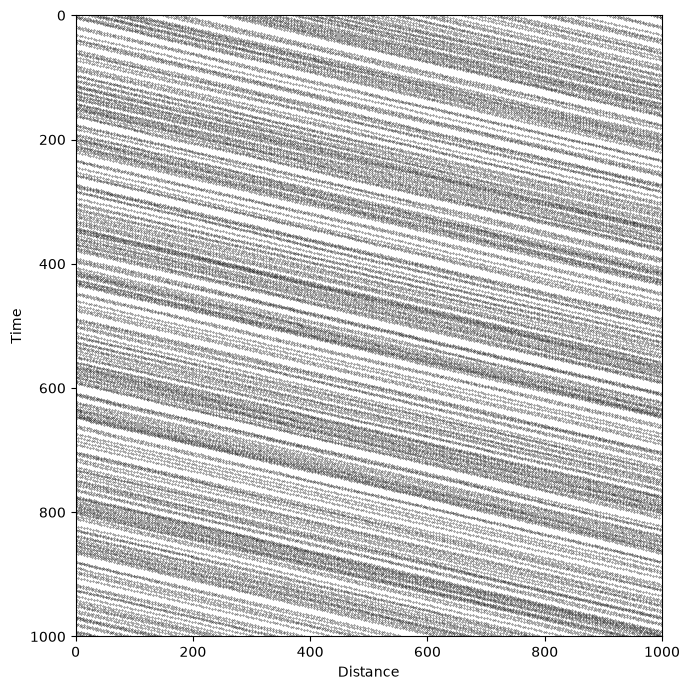

In [20]:
M = 1000 
B = 1000
k = 50 
vmax = 5
p = 1/3
steps = 1000
burn_in = 1000

dist_a, flow_a, history = nagel_sh(M, k, vmax, p, steps, burn_in, seed=42)

print(f"  Общее расстояние за 1000 шагов: {dist_a}")
print(f"  Средний поток (авто/шаг): {dist_a/1000:.2f}")

fig, ax = plt.subplots(figsize=(7, 7))

for i in range(k):
    ax.scatter(history[:, i], np.arange(steps),
               s=0.3, c='black', marker='.')

ax.set_xlabel("Distance")
ax.set_ylabel("Time")
ax.invert_yaxis() 
ax.set_xlim(0, M)
ax.set_ylim(steps, 0)

plt.tight_layout()
plt.show()

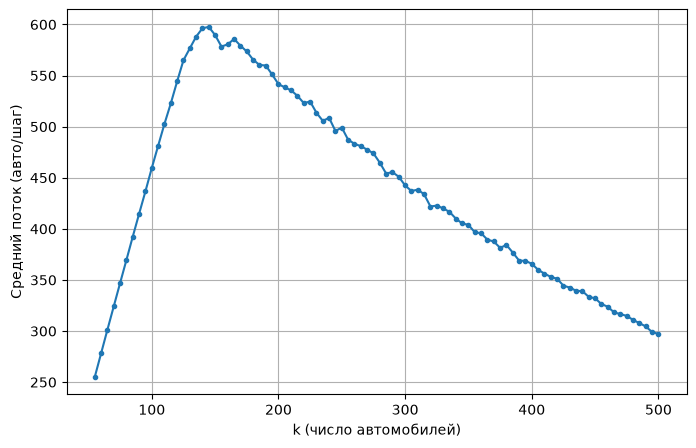

Максимум потока при k ≈ 145: flow = 597.6550
Выбраны k1=55 (свободный поток) и k2=345 (пробки)


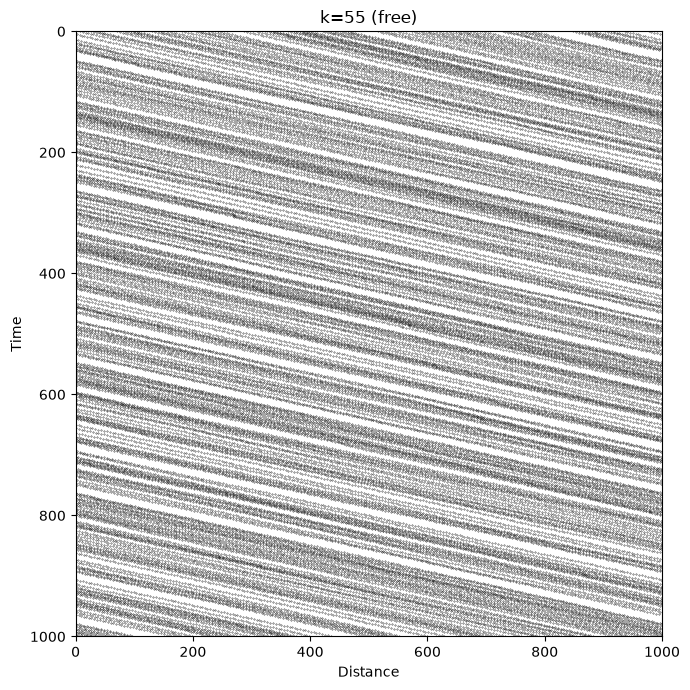

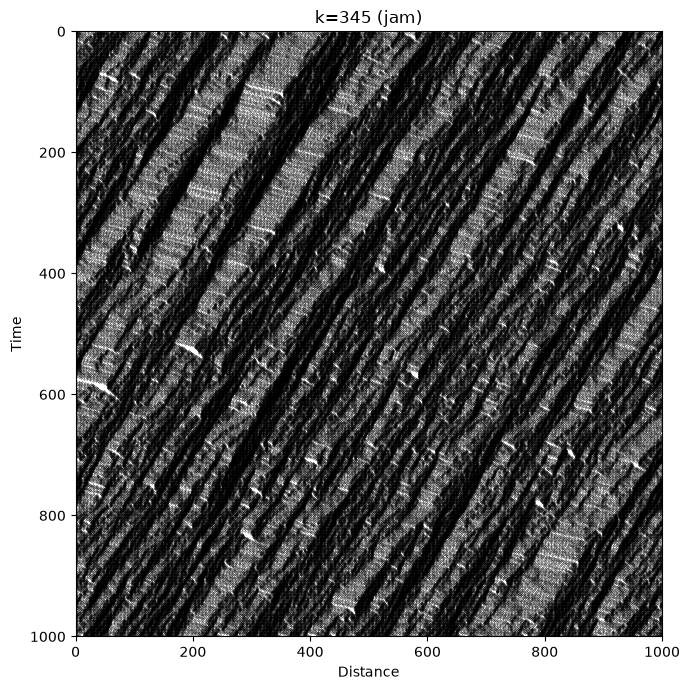

In [ ]:
ks = list(range(55, 501, 5))
flows_b = np.empty(len(ks))

for i, k in enumerate(ks):
    d, _, _ = nagel_sh(M, k, vmax, p, steps=1000, burn_in=B, seed=1234)
    flows_b[i] = d / 1000

plt.figure(figsize=(8, 5))
plt.plot(ks, flows_b, 'o-', ms=3)
plt.xlabel("k (число автомобилей)")
plt.ylabel("Средний поток (авто/шаг)")
plt.grid(True)
plt.show()

k_max_idx = np.argmax(flows_b)
k_max = ks[k_max_idx]
print(f"Максимум потока при k ≈ {k_max}: flow = {flows_b[k_max_idx]:.4f}")

k1 = ks[max(0, k_max_idx - 20)]  
k2 = ks[min(len(ks)-1, k_max_idx + 40)] 
print(f"Выбраны k1={k1} (свободный поток) и k2={k2} (пробки)")

for kk, tag in [(k1, "free"), (k2, "jam")]:
    _, _, hist = nagel_sh(M, kk, vmax, p,
                                     steps=1000, burn_in=B,
                                     init='uniform', seed=7)
    fig, ax = plt.subplots(figsize=(7, 7))
    for i in range(kk):
        ax.scatter(hist[:, i], np.arange(1000), s=0.3, c='black', marker='.')
    ax.set_xlabel("Distance"); ax.set_ylabel("Time")
    ax.set_title(f"k={kk} ({tag})")
    ax.invert_yaxis(); ax.set_xlim(0, M); ax.set_ylim(1000, 0)
    plt.tight_layout(); plt.show()

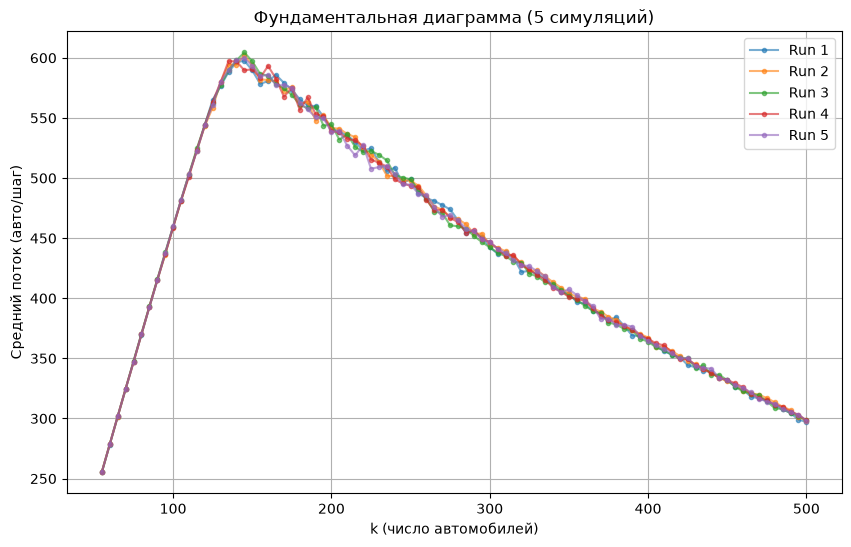

Максимальный средний поток: 598.7778
Диапазон k для максимальной пропускной способности: от 140 до 150


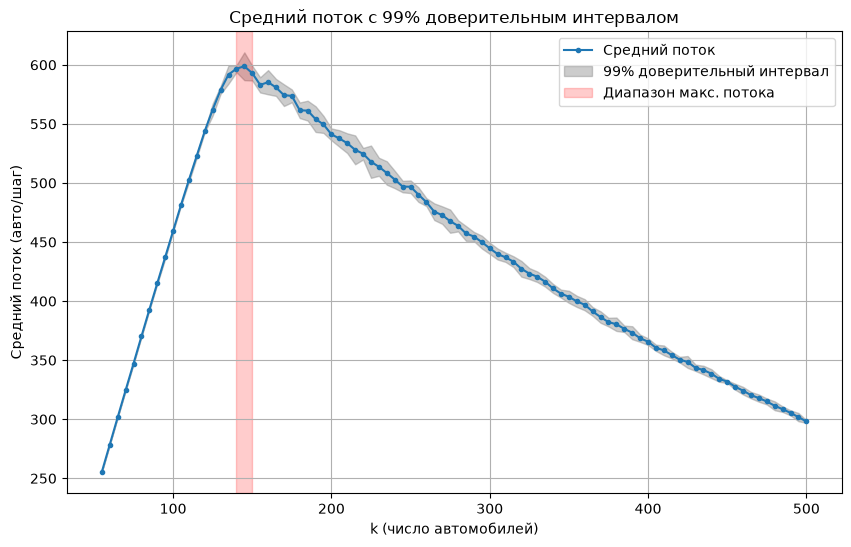

In [14]:
all_flows = []
all_flows.append(flows_b)

for i in range(4):
    flows_run = np.empty(len(ks))
    seed_val = 100 + i 
    for j, k in enumerate(ks):
        dist, _, _ = nagel_sh(M, k, vmax, p, steps=1000,
                                     burn_in=B, init='uniform', seed=seed_val)
        flows_run[j] = dist / 1000
    all_flows.append(flows_run)

all_flows = np.array(all_flows)

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(ks, all_flows[i], 'o-', ms=3, alpha=0.6, label=f'Run {i+1}')
plt.xlabel("k (число автомобилей)")
plt.ylabel("Средний поток (авто/шаг)")
plt.title("Фундаментальная диаграмма (5 симуляций)")
plt.legend()
plt.grid(True)
plt.show()

mean_flow = np.mean(all_flows, axis=0)
std_flow = np.std(all_flows, axis=0, ddof=1)

t_val = stats.t.ppf(0.995, df=4)
ci_99 = t_val * (std_flow / np.sqrt(5))

plt.figure(figsize=(10, 6))
plt.plot(ks, mean_flow, 'o-', ms=3, label='Средний поток')
plt.fill_between(ks, mean_flow - ci_99, mean_flow + ci_99, color='gray', alpha=0.4, label='99% доверительный интервал')

max_mean_flow = np.max(mean_flow)
threshold = 0.99 * max_mean_flow
high_flow_indices = np.where(mean_flow >= threshold)[0]
k_range_max_flow = (ks[high_flow_indices[0]], ks[high_flow_indices[-1]])

print(f"Максимальный средний поток: {max_mean_flow:.4f}")
print(f"Диапазон k для максимальной пропускной способности: от {k_range_max_flow[0]} до {k_range_max_flow[1]}")

plt.axvspan(k_range_max_flow[0], k_range_max_flow[1], color='red', alpha=0.2, label=f'Диапазон макс. потока')
plt.xlabel("k (число автомобилей)")
plt.ylabel("Средний поток (авто/шаг)")
plt.title("Средний поток с 99% доверительным интервалом")
plt.legend()
plt.grid(True)
plt.show()

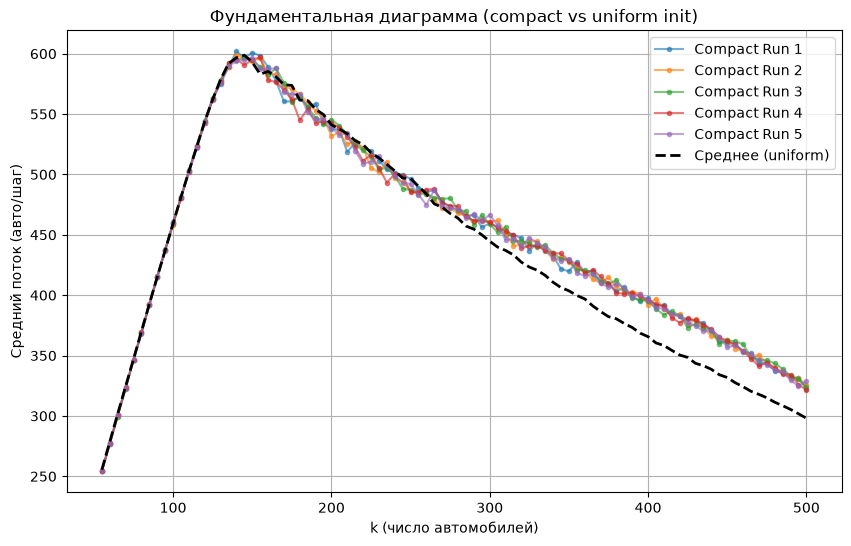

In [15]:
plt.figure(figsize=(10, 6))

for i in range(5):
    flows_compact = np.empty(len(ks))
    seed_val = 200 + i
    for j, k in enumerate(ks):
        dist, _, _ = nagel_sh(M, k, vmax, p, steps=1000,
                                     burn_in=B, init='compact', seed=seed_val)
        flows_compact[j] = dist / 1000
    plt.plot(ks, flows_compact, 'o-', ms=3, alpha=0.6, label=f'Compact Run {i+1}')

plt.plot(ks, mean_flow, 'k--', linewidth=2, label='Среднее (uniform)')

plt.xlabel("k (число автомобилей)")
plt.ylabel("Средний поток (авто/шаг)")
plt.title("Фундаментальная диаграмма (compact vs uniform init)")
plt.legend()
plt.grid(True)
plt.show()